<a href="https://colab.research.google.com/github/rogon666/UMSA/blob/main/UMSA_2026_001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        count         mean          std          min          25%  \
sex                                                                 
Men    5000.0  5003.809690  1525.192981  1530.289949  3910.588191   
Women  5000.0  2432.320062  1904.580069   110.056306  1194.555264   

               50%          75%           max  
sex                                            
Men    4782.894187  5860.555449  14064.306142  
Women  1898.000653  3084.562602  21046.883130  


<Figure size 1000x600 with 0 Axes>

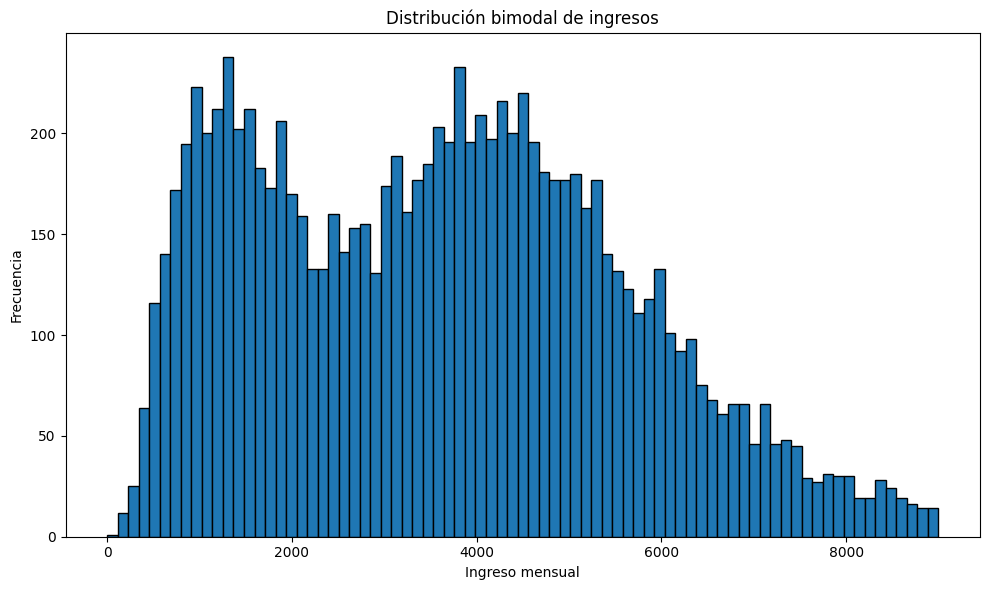

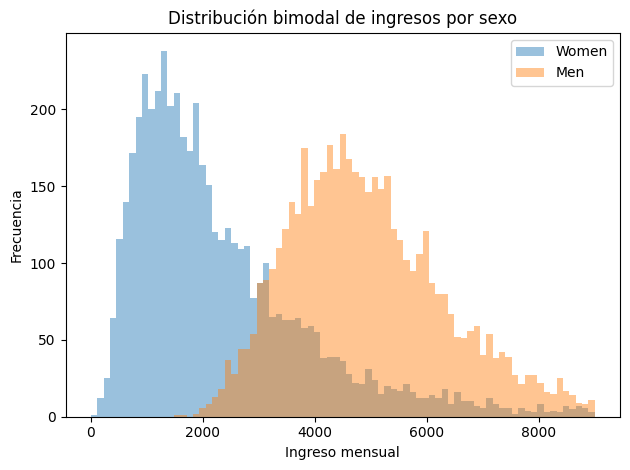

In [15]:
# ==========================================================
# Maestría en Ciencia y Análisis de Datos
# Universidad Mayor de San Andrés
# ----------------------------------------------------------
#    Modelos lineales y modelos lineales generalizados
# ----------------------------------------------------------
#        Rolando Gonzales Martinez, Julio 2026
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# Simulación de ingresos: mezcla bimodal hombres / mujeres
# ------------------------------------------------------------

np.random.seed(666)

# Tamaño muestral
n_women = 5000
n_men = 5000

# Parámetros deseados en escala monetaria
# Estos valores son ficticios y solo sirven para ilustración.
mean_women = 2500
mean_men = 5000

# Dispersión lognormal
# Valores más bajos hacen que los grupos estén más separados visualmente.
sigma_women = 0.7
sigma_men = 0.3

# Convertir media deseada a parámetro mu de la lognormal
# Si X ~ Lognormal(mu, sigma^2), entonces E[X] = exp(mu + sigma^2 / 2)
mu_women = np.log(mean_women) - 0.5 * sigma_women**2
mu_men = np.log(mean_men) - 0.5 * sigma_men**2

# Generar ingresos
income_women = np.random.lognormal(mean=mu_women, sigma=sigma_women, size=n_women)
income_men = np.random.lognormal(mean=mu_men, sigma=sigma_men, size=n_men)

# Crear base de datos
df = pd.DataFrame({
    "income": np.concatenate([income_women, income_men]),
    "sex": ["Women"] * n_women + ["Men"] * n_men
})

# Estadísticas descriptivas
print(df.groupby("sex")["income"].describe())

# ------------------------------------------------------------
# Gráfico: histogramas por grupo y distribución total
# ------------------------------------------------------------

# Single histogram of the total income distribution
plt.figure(figsize=(4, 3))

bins = np.linspace(0, 9000, 80)

plt.hist(
    df["income"],
    bins=bins,
    density=False,
    edgecolor="black"
)

plt.xlabel("Ingreso mensual")
plt.ylabel("Frecuencia")
plt.title("Distribución bimodal de ingresos")
plt.tight_layout()
plt.show()

plt.hist(
    income_women,
    bins=bins,
    alpha=0.45,
    density=False,
    label="Women"
)

plt.hist(
    income_men,
    bins=bins,
    alpha=0.45,
    density=False,
    label="Men"
)

plt.xlabel("Ingreso mensual")
plt.ylabel("Frecuencia")
plt.title("Distribución bimodal de ingresos por sexo")
plt.legend()
plt.tight_layout()
plt.show()

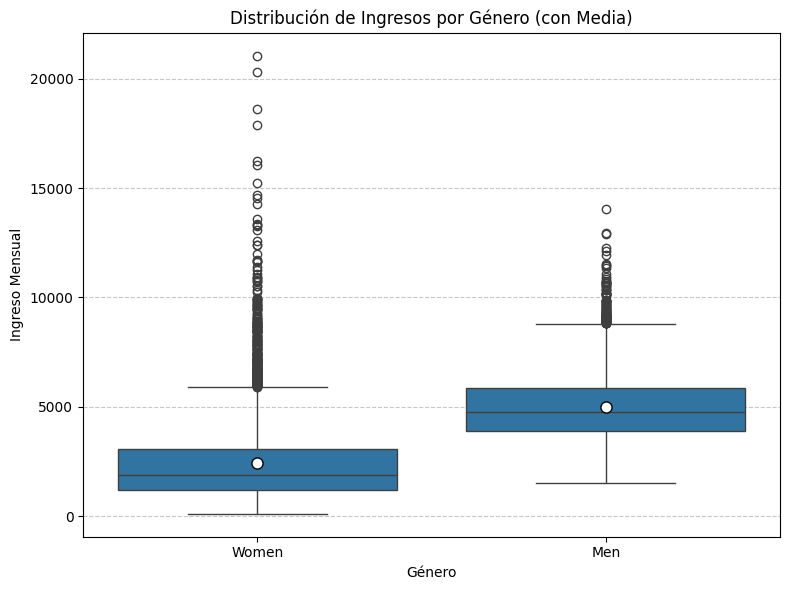

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='sex', y='income', data=df, showmeans=True,
            meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black',
                       'markersize':'8'})
plt.title('Distribución de Ingresos por Género (con Media)')
plt.xlabel('Género')
plt.ylabel('Ingreso Mensual')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()